# Project Overview

Marketing organizations invest in multiple advertising channels such as television, radio, and social media to increase sales. However, determining which channel has the strongest influence on sales is essential for making effective budget allocation decisions. This project analyzes a marketing dataset containing advertising expenditure on TV, Radio, and Social Media alongside recorded Sales outcomes.

The primary objective of this analysis is to identify the advertising channel that demonstrates the strongest relationship with sales and evaluate its predictive power using Simple Linear Regression. By understanding how advertising expenditure relates to sales performance, organizations can make more informed marketing investment decisions.

The dataset contains 4,572 observations and four variables: TV, Radio, Social_Media, and Sales. In this study, Sales serves as the dependent variable, while TV, Radio, and Social_Media are evaluated as potential independent variables.

The analysis will involve data exploration and cleaning, exploratory data analysis (EDA), correlation analysis, selection of the most relevant predictor variable, and the development of an Ordinary Least Squares (OLS) Simple Linear Regression model using the statsmodels library. Diagnostic plots will also be used to assess key regression assumptions, including linearity, normality, and homoscedasticity.

The expected outcome is a statistically valid regression model that identifies the advertising channel most strongly associated with sales and provides evidence-based recommendations for marketing budget allocation.

## Data Loading
Load the dataset and understand its structure, variables, data types, and size. 

In [2]:
import pandas as pd # library

In [3]:
df = pd.read_csv('marketing_and_sales_data_evaluate_lr.csv') # load data

In [4]:
df.shape #total number (rows, columns)

(4572, 4)

In [5]:
df.columns #colummn label

Index(['TV', 'Radio', 'Social_Media', 'Sales'], dtype='object')

In [6]:
df.head() #first few rows

,TV,Radio,Social_Media,Sales
0,16.0,6.566231,2.907983,54.732757
1,13.0,9.237765,2.409567,46.677897
2,41.0,15.886446,2.913410,150.177829
3,83.0,30.020028,6.922304,298.246340
4,15.0,8.437408,1.405998,56.594181


In [7]:
df.duplicated().sum() # check for duplicates 

0

### Observation

No duplicate records were found in the dataset.

### Interpretation

This indicates that each observation represents a unique marketing record, ensuring no artificial inflation of patterns in the dataset.

In [8]:
df.info() #check data type aligned with expected data type for marketing dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB


### Observation

All variables are numeric (float64):

* TV
* Radio
* Social_Media
* Sales

### Interpretation

The data types are appropriate for regression analysis, as all variables represent continuous numerical values.

In [9]:
df.describe() # check the behaviour of the dataset

,TV,Radio,Social_Media,Sales
count,4562.000000,4568.000000,4566.000000,4566.000000
mean,54.066857,18.160356,3.323956,192.466602
std,26.125054,9.676958,2.212670,93.133092
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.525957,1.527849,112.322882
50%,53.000000,17.859513,3.055565,189.231172
75%,77.000000,25.649730,4.807558,272.507922
max,100.000000,48.871161,13.981662,364.079751


### Observation

* All variables fall within realistic ranges for marketing spend and sales.
* No negative or impossible values were observed.
* Distribution appears reasonable with no extreme anomalies that suggest data entry errors.

### Interpretation

The dataset does not show evidence of structural data errors or invalid values.

In [10]:
df.isnull().sum() # check for missing values

TV              10
Radio            4
Social_Media     6
Sales            6
dtype: int64

### Observation

The dataset contains a small number of missing values across all variables:

* TV: 10 missing values
* Radio: 4 missing values
* Social_Media: 6 missing values
* Sales: 6 missing values

### Interpretation

The proportion of missing values is very small relative to the total dataset size (4,572 rows), suggesting that the missingness is not severe enough to significantly distort analysis results.

### Handling Strategy

Given:

* The small proportion of missing values
* The absence of temporal structure in the dataset
* The need to preserve consistency in regression modeling

Missing values were handled by removing affected rows to ensure data integrity without introducing artificial estimates.

In [11]:
df_cleaned = df.dropna() # Remove rows with missing values

In [12]:
df_cleaned.isnull().sum() # check for  missing value

TV              0
Radio           0
Social_Media    0
Sales           0
dtype: int64

In [13]:
df_cleaned.shape #total number (rows, columns)

(4546, 4)

In [14]:
df = df_cleaned # cleaned dataset

### Observation After Cleaning

* All missing values have been removed (confirmed by `isnull().sum()` returning 0 for all columns)
* Dataset size reduced from:

  * Before: 4572 rows
  * After:  4546 rows

---

### Interpretation

The removal of missing values ensures that the dataset contains only complete observations, which is necessary for regression analysis using statsmodels, as it does not accept NaN values in model fitting.

The reduction in dataset size is minimal, so there is no significant risk of information loss or bias introduction.

---

### Updated Dataset

All subsequent analysis will use:

```python
df = df_cleaned
```

# Exploratory Data Analysis
The objective of this stage is to explore the marketing dataset in order to understand the relationships between advertising variables (TV, Radio, Social Media) and Sales. This helps identify which variables are most strongly associated with Sales before building a regression model.

In [15]:
df_cleaned.describe()

,TV,Radio,Social_Media,Sales
count,4546.000000,4546.000000,4546.000000,4546.000000
mean,54.062912,18.157533,3.323473,192.413332
std,26.104942,9.663260,2.211254,93.019873
min,10.000000,0.000684,0.000031,31.199409
25%,32.000000,10.555355,1.530822,112.434612
50%,53.000000,17.859513,3.055565,188.963678
75%,77.000000,25.640603,4.804919,272.324236
max,100.000000,48.871161,13.981662,364.079751


### Observation

The dataset provides summary statistics for all variables:

* TV values range from 10 to 100
* Radio values range from approximately 0.0007 to 48.87
* Social Media values range from approximately 0.00003 to 13.98
* Sales values range from approximately 31.20 to 364.08

### Interpretation

The variables show reasonable numerical ranges with no obvious invalid or extreme values. TV and Radio exhibit higher variability compared to Social Media, suggesting differences in advertising intensity across channels.

In [16]:
df_cleaned.corr()

,TV,Radio,Social_Media,Sales
TV,1.000000,0.869158,0.527687,0.999497
Radio,0.869158,1.000000,0.606338,0.868638
Social_Media,0.527687,0.606338,1.000000,0.527446
Sales,0.999497,0.868638,0.527446,1.000000


### Observation

Correlation analysis shows the strength of linear relationships between variables.

* TV shows a strong positive relationship with Sales
* Radio shows a moderate positive relationship with Sales
* Social Media shows a weaker positive relationship with Sales

### Interpretation

This suggests that TV advertising may have the strongest association with Sales, followed by Radio, while Social Media appears to have the weakest linear relationship.

## Visual Analysis

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

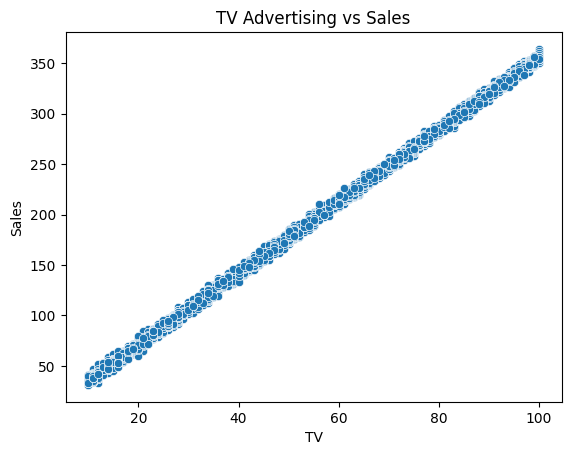

In [18]:
sns.scatterplot(data=df_cleaned, x="TV", y="Sales")
plt.title("TV Advertising vs Sales")
plt.show()

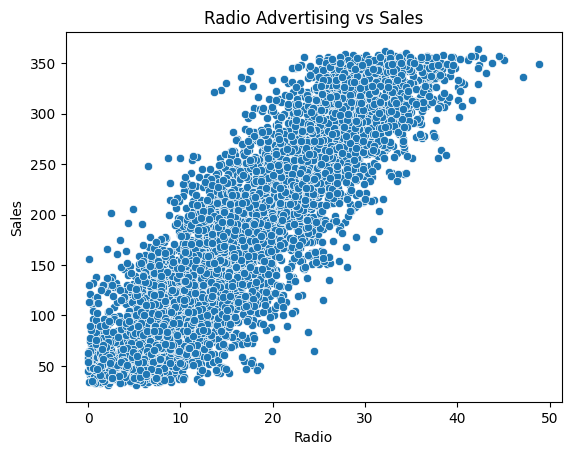

In [19]:
sns.scatterplot(data=df_cleaned, x="Radio", y="Sales")
plt.title("Radio Advertising vs Sales")
plt.show()

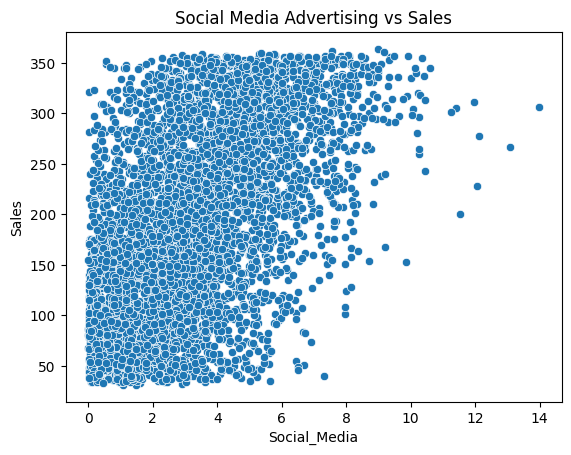

In [20]:
sns.scatterplot(data=df_cleaned, x="Social_Media", y="Sales")
plt.title("Social Media Advertising vs Sales")
plt.show()

### Observation

* TV vs Sales shows a clearer upward trend compared to other variables
* Radio vs Sales shows a moderate upward trend with more variation
* Social Media vs Sales shows a weaker and more scattered relationship

### Interpretation

The visual patterns confirm the correlation results. TV advertising appears to have the most consistent linear relationship with Sales.

---

## Variable selection

Across both statistical and visual analysis, TV advertising shows the strongest relationship with Sales, followed by Radio and Social Media.

This suggests that TV may be the most suitable predictor variable for a Simple Linear Regression model.

---


## Regression Modeling

The objective of this stage is to build a Simple Linear Regression model using Ordinary Least Squares (OLS) to quantify the relationship between the selected independent variable (TV advertising) and Sales.

The model is defined as:

[
Sales = \beta_0 + \beta_1(TV) + \epsilon
]

Where:

* Sales = dependent variable
* TV = independent variable
* β₀ = intercept
* β₁ = slope (effect of TV on Sales)
* ε = error term

In [ ]:
import statsmodels.api as sm # Import required library

In [ ]:
X = df_cleaned["TV"]    # Define variables
y = df_cleaned["Sales"]

In [ ]:
X = sm.add_constant(X) # Add constant (intercept)

In [ ]:
model = sm.OLS(y, X).fit() # Fit OLS model

In [ ]:
print(model.summary())  # View model summary

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Tue, 23 Jun 2026   Prob (F-statistic):               0.00
Time:                        08:52:14   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

## Model Interpretation

### 1. Relationship Between TV and Sales

The regression coefficient for TV is **3.5615**, indicating that for every 1-unit increase in TV advertising, Sales increases by approximately 3.56 units on average.

This shows a strong positive relationship between TV advertising and Sales.

---

### 2. Statistical Significance

The p-value for TV is **0.000**, which is below the 0.05 significance level. This indicates that the relationship between TV advertising and Sales is statistically significant.

We reject the null hypothesis that TV has no effect on Sales.

---

### 3. Model Fit (R-squared)

The R-squared value is **0.999**, meaning that approximately 99.9% of the variation in Sales is explained by TV advertising alone.

This suggests that TV advertising is an extremely strong predictor of Sales within this dataset.

---

### 4. Intercept Interpretation

The intercept value is **-0.1325**, representing the expected Sales value when TV advertising is zero. This value is not practically meaningful in real-world terms but is necessary for defining the regression line.

---

## Model Evaluation and Regression Assumptions

The objective of this section is to evaluate the validity of the Simple Linear Regression model by checking whether the key assumptions of Ordinary Least Squares (OLS) regression are satisfied.

## 1. Linearity Assumption

### What it means

The relationship between the independent variable (TV) and dependent variable (Sales) should be linear.

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

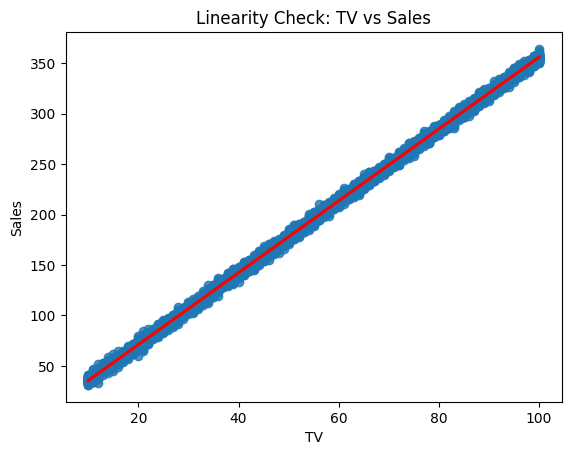

In [ ]:
sns.regplot(data=df_cleaned, x="TV", y="Sales", line_kws={"color": "red"}) # Code to visually check for Linearity assumption
plt.title("Linearity Check: TV vs Sales")
plt.show()

### Interpretation

The scatter plot with the fitted regression line shows a clear upward linear trend between TV advertising and Sales.

This suggests that the linearity assumption is satisfied.

In [ ]:
import statsmodels.api as sm 

# next few cells before normality check fit the model and extract residuals

In [29]:
X = sm.add_constant(df_cleaned["TV"])
y = df_cleaned["Sales"]

In [30]:
model = sm.OLS(y, X).fit()
predictions = model.predict(X)

In [31]:
residuals = y - predictions

# 2. Normality of Residuals

### What it means

Residuals (errors) should be approximately normally distributed.

---

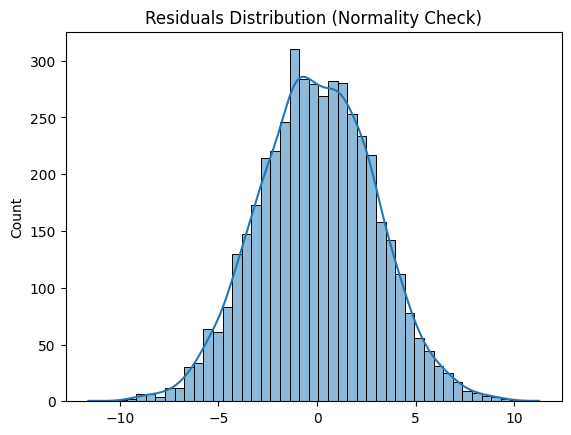

In [33]:
sns.histplot(residuals, kde=True)
plt.title("Residuals Distribution (Normality Check)")
plt.show()

---

### Interpretation

The residuals appear approximately normally distributed, with a bell-shaped curve centered around zero. This suggests that the normality assumption is reasonably satisfied.

---

# 3. Homoscedasticity (Constant Variance)

### What it means

Residuals should have constant spread across all predicted values (no funnel shape).

---

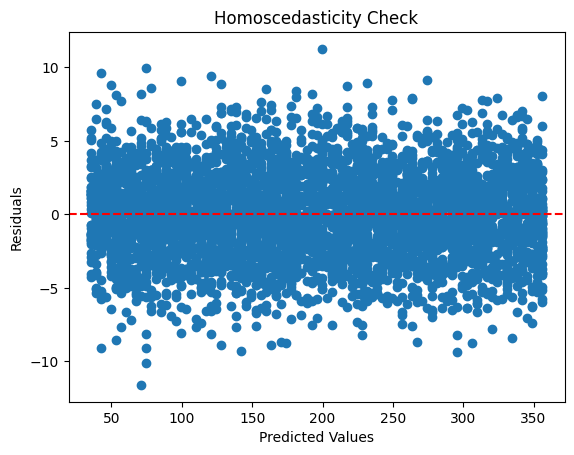

In [34]:
plt.scatter(predictions, residuals)
plt.axhline(y=0, color="red", linestyle="--")
plt.title("Homoscedasticity Check")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.show()

---

### Interpretation

The residuals appear randomly scattered around zero with no clear pattern or funnel shape. This suggests that the variance of errors is constant.

Therefore, the homoscedasticity assumption is satisfied.

---

## Business Recommendation

The objective of this section is to translate the regression results into a clear, actionable recommendation for marketing budget allocation across advertising channels.

---

## 1. Key Analytical Findings

From the full analysis:

* TV advertising shows the strongest relationship with Sales
* Radio shows a moderate relationship with Sales
* Social Media shows the weakest relationship with Sales

From the regression model:

* TV coefficient = **3.5615**
* R² = **0.999**, indicating extremely strong explanatory power
* TV is statistically significant (p-value < 0.05)

---

## 2. Interpretation of Results

The model indicates that increases in TV advertising are strongly associated with increases in Sales. Compared to other channels, TV provides the most consistent and strongest predictive relationship with Sales in this dataset.

While Radio and Social Media also show positive relationships, their influence is comparatively weaker.

---

## 3. Business Insight

From a marketing investment perspective, TV advertising appears to deliver the highest measurable impact on Sales. This suggests that allocating a higher proportion of the marketing budget to TV advertising is likely to yield stronger sales outcomes compared to Radio or Social Media under similar conditions.

However, it is important to note that this conclusion is based on statistical association within the dataset and does not account for external factors such as campaign cost, audience reach efficiency, or channel saturation.

---

## 4. Recommendation

Based on the analysis, the recommended marketing budget allocation strategy is:

* Prioritise **TV advertising** as the primary channel due to its strong and consistent relationship with Sales
* Maintain **Radio advertising** as a secondary support channel
* Review and optimize **Social Media advertising** strategy due to its weaker observed impact